In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data,columns=diabetes.feature_names)
df['target'] = diabetes.target
print(df.head())


        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


In [ ]:
df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


# **A. Normal Curve Plotting**

Plot Normal Curve for BMI Feature

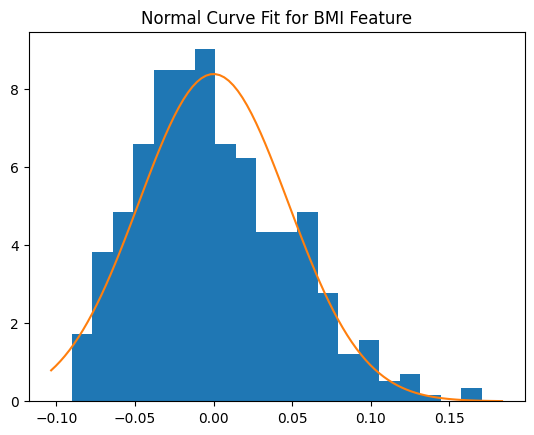

In [ ]:
data = df['bmi']

mu, std = norm.fit(data)

plt.hist(data, bins=20, density=True)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

p = norm.pdf(x, mu, std)

plt.plot(x, p)
plt.title("Normal Curve Fit for BMI Feature")
plt.show()


# **B. Density and Contour Plots**

Density Plot (KDE) for Blood Pressure

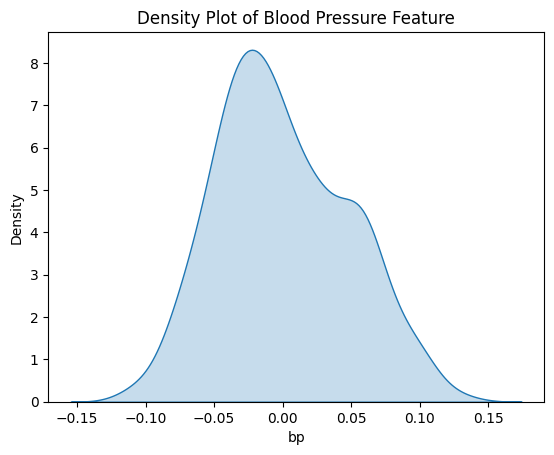

In [ ]:
sns.kdeplot(df['bp'], fill=True)
plt.title("Density Plot of Blood Pressure Feature")
plt.show()


Contour Plot for BMI vs Blood Pressure

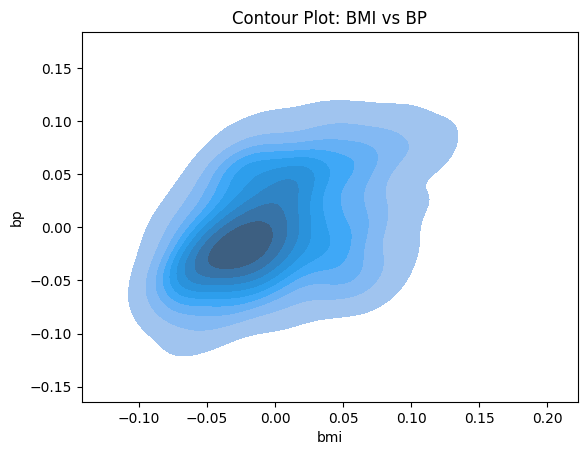

In [ ]:
sns.kdeplot(
    x=df['bmi'],
    y=df['bp'],
    fill=True
)

plt.title("Contour Plot: BMI vs BP")
plt.show()


Interpretation for BMI vs Blood Pressure:

The x-axis represents 'bmi' and the y-axis represents 'bp'.
The contours and shaded areas show combinations of BMI and Blood Pressure where the data points are most concentrated.
Areas with denser (darker or more tightly packed) contours indicate a higher frequency of individuals having those specific combinations of BMI and Blood Pressure.
This plot helps to identify any correlations or relationships between BMI and Blood Pressure, such as whether higher BMI values tend to be associated with higher blood pressure, or if there are specific clusters of individuals with certain BMI and BP characteristics.

# **C. Correlation and Scatter Plots**

Scatter Plot Between BMI and Target

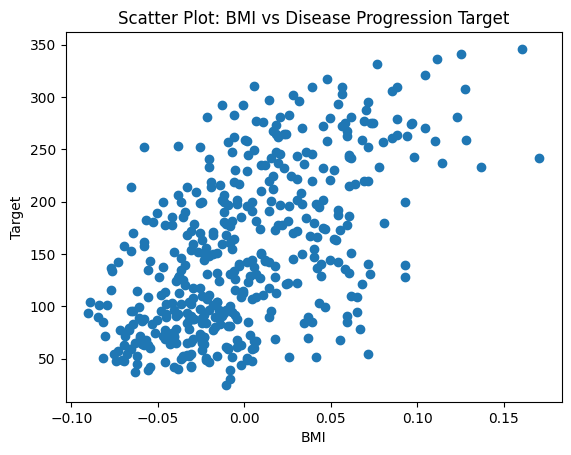

In [ ]:
plt.scatter(df['bmi'], df['target'])
plt.title("Scatter Plot: BMI vs Disease Progression Target")
plt.xlabel("BMI")
plt.ylabel("Target")
plt.show()




*   Each dot corresponds to one patient, showing their BMI and their corresponding disease progression target value.

*   By observing the pattern of the dots, you can infer the relationship between BMI and disease progression. For instance, if the dots tend to go upwards from left to right, it suggests a positive correlation (as BMI increases, the target value tends to increase). If the dots form a downward trend, it indicates a negative correlation. A scattered cloud of points with no clear direction suggests little to no linear correlation. This plot can help visualize if higher BMI values are generally associated with higher or lower disease progression targets.



Correlation Heatmap

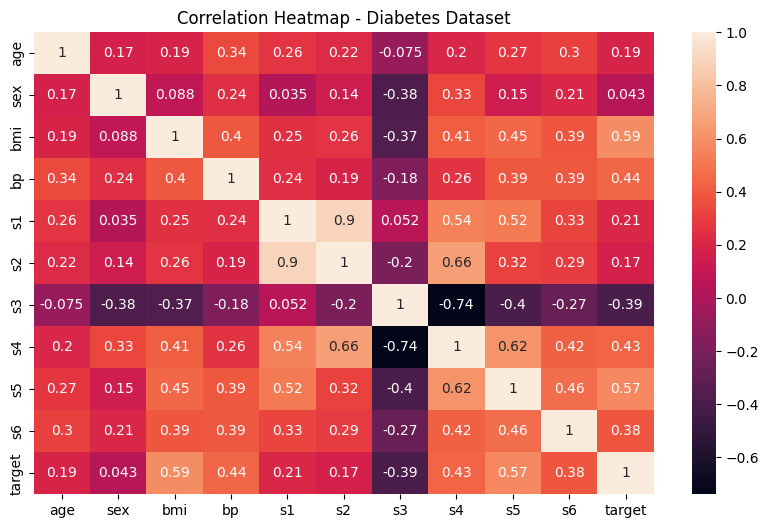

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(), annot=True)

plt.title("Correlation Heatmap - Diabetes Dataset")
plt.show()


# **D. Histogram Plotting**

Histogram of Age Feature

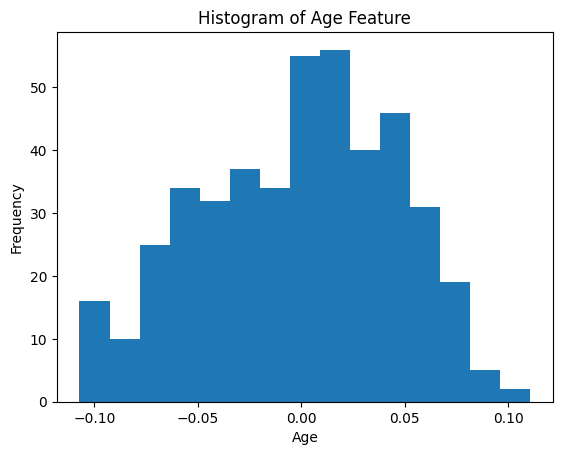

In [ ]:
plt.hist(df['age'], bins=15)
plt.title("Histogram of Age Feature")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


Multiple Histograms

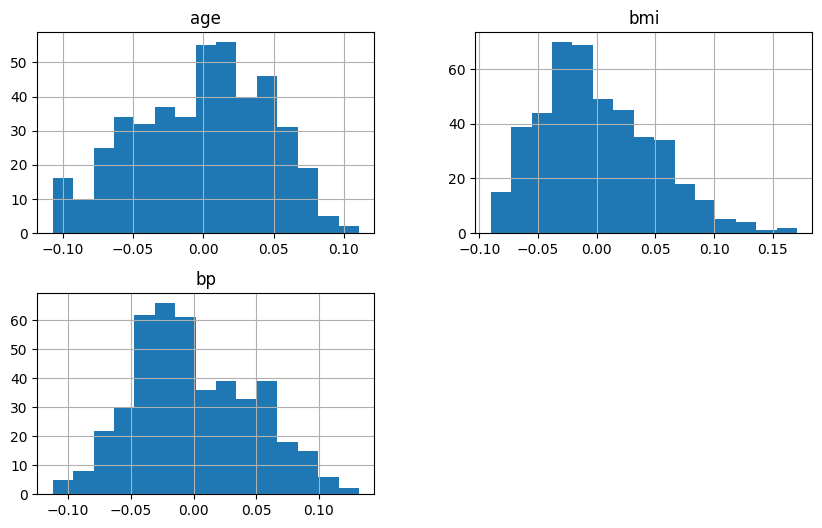

In [ ]:
df[['age','bmi','bp']].hist(bins=15, figsize=(10,6))
plt.show()


# **E. Three Dimensional Plotting**

3D Scatter Plot (BMI, BP, Target)

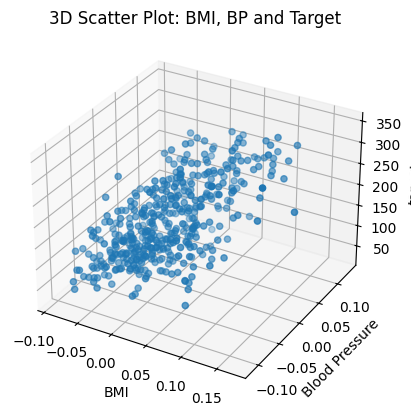

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['bmi'],
    df['bp'],
    df['target']
)

ax.set_xlabel("BMI")
ax.set_ylabel("Blood Pressure")
ax.set_zlabel("target")

plt.title("3D Scatter Plot: BMI, BP and Target")
plt.show()


Pair Plot


In [ ]:
# sns.pairplot(df[['bmi','bp','s5','target']])
# plt.show()
